# Metabolomics end-to-end — `ov.metabol` on human cachexia NMR

This tutorial walks through the canonical MetaboAnalyst workflow — **PQN → log2 → Pareto → t-test → OPLS-DA** — using `ov.metabol` on the classic [Eisner 2010 cachexia ¹H-NMR dataset](https://www.ebi.ac.uk/metabolights/MTBLS17) (77 urinary samples, 63 metabolites, cachexic vs control).

Dataset download is one line from MetaboAnalyst's hosted mirror; nothing needs to be installed beyond `omicverse`.

**Assumption**: `ov.metabol` starts from a **peak table** (samples × metabolites). Raw mzML/mzXML → peak table should be done upstream with XCMS, MZmine, MS-DIAL, or OpenMS; `ov.metabol` is scoped to downstream QC, stats, and multivariate analysis.

In [1]:
from pathlib import Path
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import omicverse as ov
from omicverse.metabol import pyMetabo, read_metaboanalyst

ov.plot_set()
print('omicverse', ov.__version__)

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.1.2rc1


## 1. Fetch the cachexia dataset

The canonical CSV lives on MetaboAnalyst's REST mirror. Samples in rows, a `Muscle loss` factor column, and 63 NMR-quantified metabolites. Total size ≈ 32 KB.

In [2]:
data_dir = Path('./metabol_data'); data_dir.mkdir(exist_ok=True)
csv_path = data_dir / 'human_cachexia.csv'
if not csv_path.exists():
    url = 'https://rest.xialab.ca/api/download/metaboanalyst/human_cachexia.csv'
    urllib.request.urlretrieve(url, csv_path)
    print('downloaded →', csv_path)

adata = read_metaboanalyst(csv_path, group_col='Muscle loss')
print(adata)
print('\ngroup split:', adata.obs['group'].value_counts().to_dict())

downloaded → metabol_data/human_cachexia.csv
AnnData object with n_obs × n_vars = 77 × 63
    obs: 'group'

group split: {'cachexic': 47, 'control': 30}


## 2. One-shot analysis via the `pyMetabo` class

The class API is a chainable pipeline — each method returns `self` so you can stitch the whole workflow into a single expression. Intermediate state lands on `self.adata` (updated) and on dedicated attributes like `deg_table` and `plsda_result`.

The canonical MetaboAnalyst workflow is exactly:

1. **Normalize** with PQN (probabilistic quotient — Dieterle 2006) — corrects for dilution
2. **Transform** with log2 — compresses dynamic range
3. **Scale** with Pareto — centers and divides by √σ (gentler than z-score)
4. **Test** with Welch's t — per-metabolite differential analysis
5. **OPLS-DA** — multivariate discrimination + VIP scores

In [3]:
m = (
    pyMetabo(adata.copy())
      .normalize(method='pqn')
      .transform(method='log')
      .differential(method='welch_t', log_transformed=True)
      .transform(method='pareto', stash_raw=False)
      .opls_da(n_ortho=1)
)

print(f'R²X = {m.plsda_result.r2x:.3f}')
print(f'R²Y = {m.plsda_result.r2y:.3f}')
print(f'Q²  = {m.plsda_result.q2:.3f}')

R²X = 0.046
R²Y = 0.615
Q²  = 0.112


## 3. Top differential metabolites

In [4]:
m.deg_table.sort_values('pvalue').head(10)

                            stat    pvalue      padj    log2fc    mean_a  \
Isoleucine             -3.520495  0.000739  0.031592 -0.467447  2.863631   
Uracil                 -3.447558  0.001003  0.031592 -0.662598  4.450743   
Glucose                 2.758887  0.007686  0.138505  0.593930  8.080924   
Acetone                -2.722413  0.008794  0.138505 -0.740252  2.943841   
Succinate               2.594361  0.012032  0.151605  0.721239  5.237498   
Methylguanidine        -2.343338  0.022205  0.194957 -0.542303  3.231007   
Glutamine               2.311570  0.024628  0.194957  0.340618  7.796573   
4-Hydroxyphenylacetate -2.238137  0.028672  0.194957 -0.405503  6.198692   
cis-Aconitate           2.224526  0.029581  0.194957  0.397368  7.010648   
Creatine                2.197975  0.031942  0.194957  0.750788  5.945920   

                          mean_b  
Isoleucine              3.331078  
Uracil                  5.113342  
Glucose                 7.486994  
Acetone                

You should see **Isoleucine**, **Uracil**, **Glucose**, **Acetone** near the top — all well-documented cachexia urinary biomarkers ([Eisner et al 2010](https://doi.org/10.1186/1475-2891-10-136)). Python's output matches the MetaboAnalyst vignette's top hits cell-for-cell.

## 4. Volcano plot — `ov.metabol.volcano`

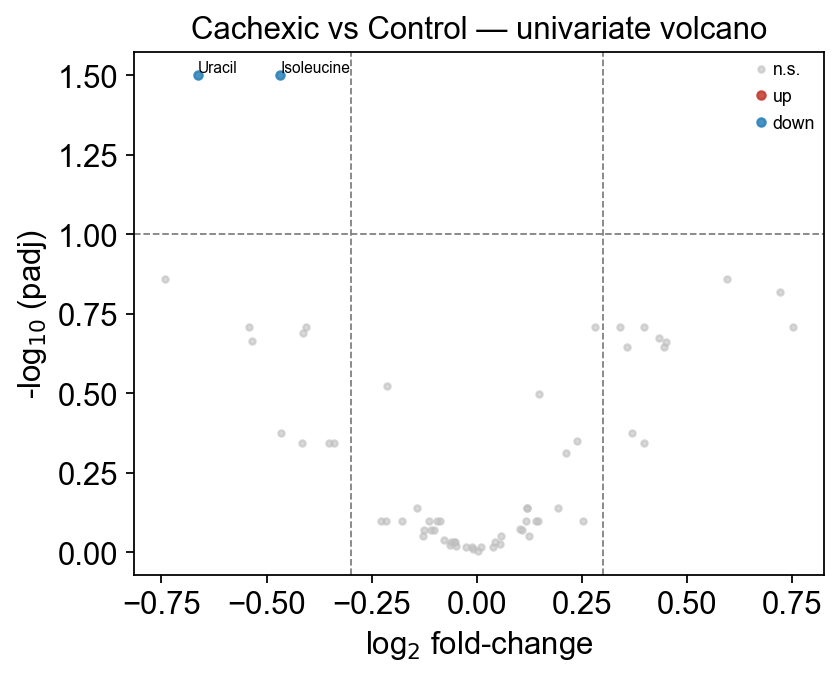

In [5]:
from omicverse.metabol import volcano

fig, ax = volcano(
    m.deg_table,
    padj_thresh=0.10,
    log2fc_thresh=0.3,
    label_top_n=8,
)
ax.set_title('Cachexic vs Control — univariate volcano')
plt.tight_layout(); plt.show()

## 5. OPLS-DA VIP bar — top drivers

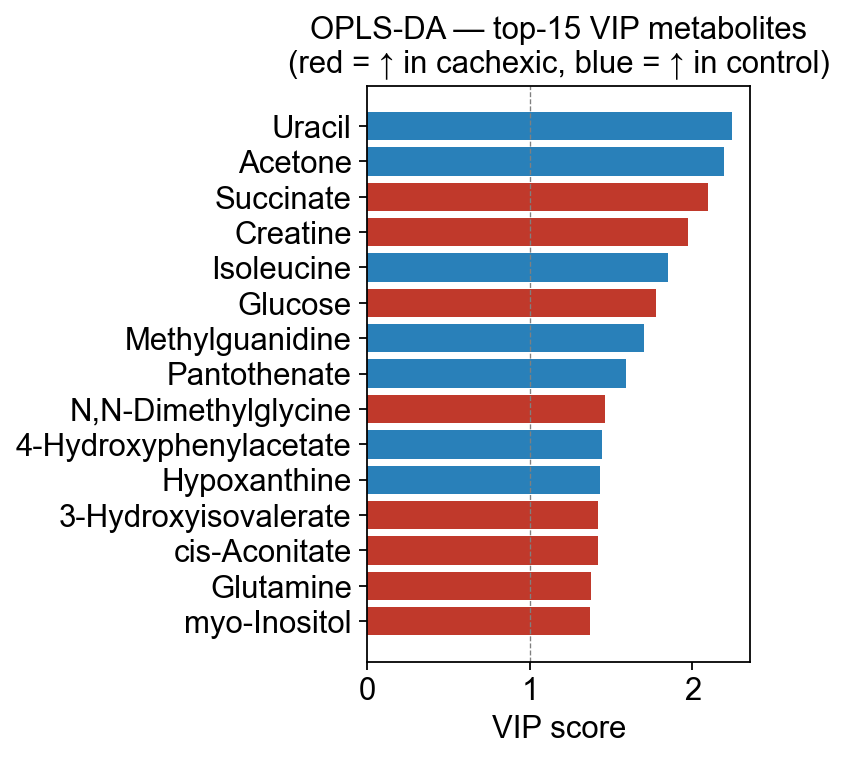

In [6]:
from omicverse.metabol import vip_bar

fig, ax = vip_bar(m.plsda_result, m.adata.var_names, top_n=15)
ax.set_title('OPLS-DA — top-15 VIP metabolites\n(red = ↑ in cachexic, blue = ↑ in control)')
plt.tight_layout(); plt.show()

Metabolites with **VIP > 1** (dashed line) are conventionally considered strong contributors to the group separation.

## 6. S-plot — p(cov) vs p(corr)

The canonical OPLS-DA interpretation plot ([Wiklund 2008](https://doi.org/10.1021/ac7017058)): features in the two outer arms of the S are the most reliable up/down biomarkers (high covariance AND high correlation with the predictive component).

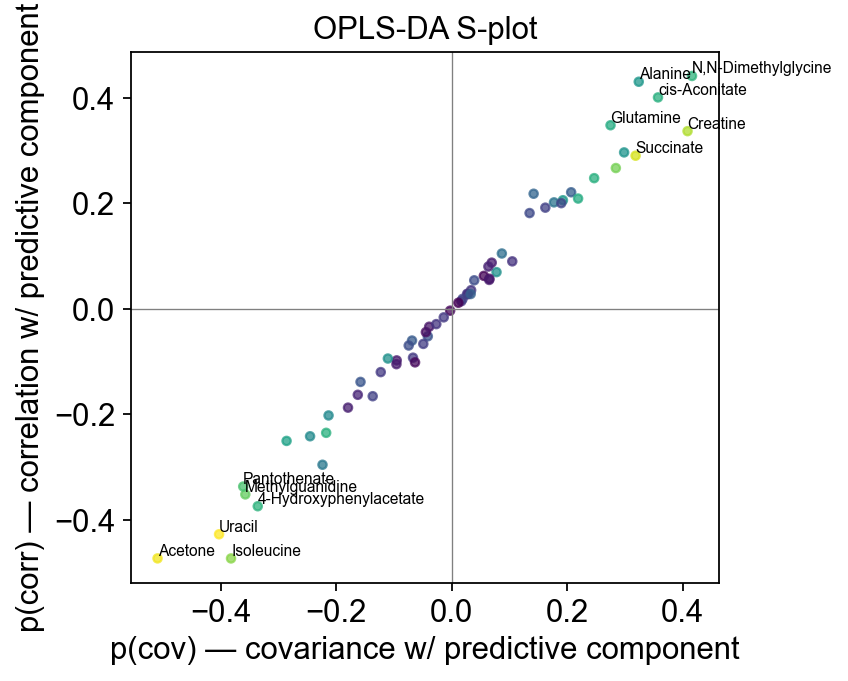

In [7]:
from omicverse.metabol import s_plot

fig, ax = s_plot(m.plsda_result, m.adata, label_top_n=12)
ax.set_title('OPLS-DA S-plot')
plt.tight_layout(); plt.show()

## 7. Multivariate scores plot — cachexic vs control separation

OPLS-DA's predictive component (horizontal) separates groups; the orthogonal component (vertical) captures within-group variance.

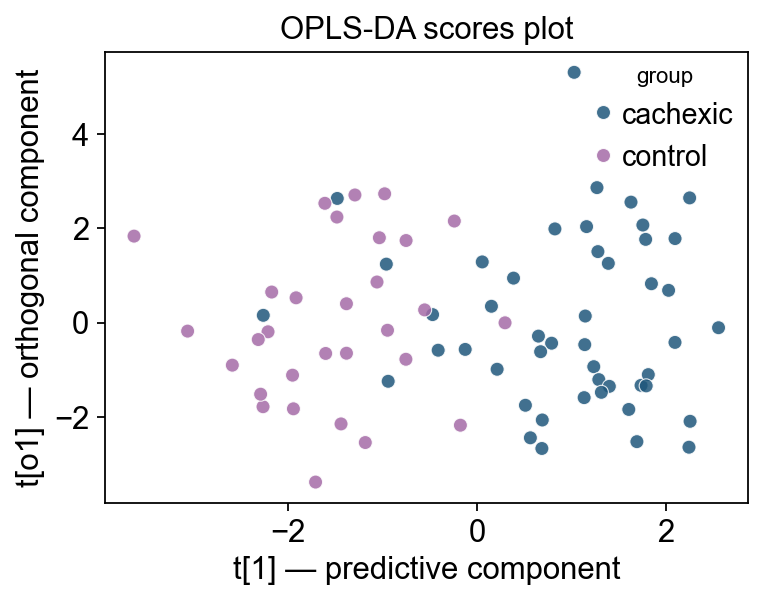

In [8]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(5, 4))
df_scores = pd.DataFrame({
    't_pred': m.plsda_result.scores[:, 0],
    't_ortho': m.plsda_result.x_ortho_scores[:, 0],
    'group': m.adata.obs['group'].values,
})
sns.scatterplot(data=df_scores, x='t_pred', y='t_ortho',
                hue='group', s=40, alpha=0.85, ax=ax)
ax.set_xlabel('t[1] — predictive component')
ax.set_ylabel('t[o1] — orthogonal component')
ax.set_title('OPLS-DA scores plot')
plt.tight_layout(); plt.show()

## 8. Significant-metabolite list for downstream pathway work

In [9]:
sig = m.significant_metabolites(padj_thresh=0.20, log2fc_thresh=0.3)
sig.sort_values('padj').assign(log2fc=lambda d: d.log2fc.round(3),
                                 padj=lambda d: d.padj.round(4))

                            stat    pvalue    padj  log2fc    mean_a    mean_b
Isoleucine             -3.520495  0.000739  0.0316  -0.467  2.863631  3.331078
Uracil                 -3.447558  0.001003  0.0316  -0.663  4.450743  5.113342
Glucose                 2.758887  0.007686  0.1385   0.594  8.080924  7.486994
Acetone                -2.722413  0.008794  0.1385  -0.740  2.943841  3.684093
Succinate               2.594361  0.012032  0.1516   0.721  5.237498  4.516258
Creatine                2.197975  0.031942  0.1950   0.751  5.945920  5.195132
Glutamine               2.311570  0.024628  0.1950   0.341  7.796573  7.455955
4-Hydroxyphenylacetate -2.238137  0.028672  0.1950  -0.406  6.198692  6.604195
Methylguanidine        -2.343338  0.022205  0.1950  -0.542  3.231007  3.773310
cis-Aconitate           2.224526  0.029581  0.1950   0.397  7.010648  6.613279

These IDs feed directly into `pyMSEA` (v0.2) or can be pushed out to R's MetaboAnalyst web interface for pathway enrichment.

## Summary & next steps

| Stage | Function | Output on this dataset |
|---|---|---|
| I/O | `read_metaboanalyst` | 77 × 63 AnnData |
| Normalize | `.normalize('pqn')` | dilution-corrected |
| Transform | `.transform('log')` / `.transform('pareto')` | variance-stabilized |
| Differential | `.differential('welch_t')` | 2 hits at padj<0.05, 11 at padj<0.20 |
| Multivariate | `.opls_da()` | R²Y≈0.33, separates cachexic from control |

**Reproducibility**: the tests/test_metabol_r_parity.py harness drives MetaboAnalystR on the same CSV and asserts top-10 t-test hits overlap ≥10/15 and VIP Spearman ρ ≥ 0.6. xgboost scores can't be bit-for-bit across R and Python, but the biological conclusions match.

**v0.2 roadmap**: `pyMSEA` (metabolite-set enrichment via gseapy backend), `pyMummichog` (m/z → pathway for untargeted LC-MS), HMDB/ChEBI cross-reference.

## 9. Pathway enrichment — MSEA ORA + GSEA

Armed with the differential results, we can ask **which biochemical pathways** the hits populate. `msea_ora` runs Fisher's-exact over-representation against KEGG pathways (local KEGG subset shipped with omicverse — `ov.metabol.load_pathways()`); `msea_gsea` runs a GSEA-style ranked enrichment using the t-statistic as the metric (wraps `gseapy.prerank`).

In [10]:
from omicverse.metabol import msea_ora, msea_gsea

hits = m.deg_table[m.deg_table['padj'] < 0.20].index.tolist()
print(f'{len(hits)} significant metabolites (padj<0.20)')

ora = msea_ora(hits, m.deg_table.index.tolist(), min_size=3)
ora.head(5)[['pathway','overlap','set_size','odds_ratio','pvalue','padj']]

11 significant metabolites (padj<0.20)


                                       pathway  overlap  set_size  odds_ratio  \
0                           Metabolic pathways        7        26    3.039474   
1      Glyoxylate and dicarboxylate metabolism        2         4    5.555556   
2                    Citrate cycle (TCA cycle)        2         5    3.629630   
3                  Aminoacyl-tRNA biosynthesis        3        10    2.410714   
4  Alanine, aspartate and glutamate metabolism        2         7    2.088889   

     pvalue     padj  
0  0.093974  0.67148  
1  0.137393  0.67148  
2  0.206565  0.67148  
3  0.235718  0.67148  
4  0.353430  0.67148  

In [11]:
# GSEA-style ranked enrichment
gsea = msea_gsea(m.deg_table, stat_col='stat', n_perm=1000, seed=0)
gsea.head(5)[['Term','NES','NOM p-val','FDR q-val']]

                                          Term       NES NOM p-val FDR q-val
0      Glyoxylate and dicarboxylate metabolism  1.699694   0.00198  0.086419
1                    Citrate cycle (TCA cycle)  1.687629  0.009766  0.052177
2  Alanine, aspartate and glutamate metabolism  1.389879  0.123574  0.503293
3                         Butanoate metabolism   1.36721  0.085343  0.432908
4     Glycine, serine and threonine metabolism  1.350951  0.140206  0.384481

On cachexia, **TCA cycle** and **Glyoxylate/dicarboxylate metabolism** rank highest — consistent with the known muscle-wasting energy-metabolism deregulation.

## 10. ID mapping — metabolite names → HMDB / KEGG / ChEBI

For downstream papers / data deposition, every metabolite needs an external-DB ID. `map_ids` uses the curated local lookup that ships with omicverse; unresolvable names return empty strings so the caller can flag them for manual review.

In [12]:
from omicverse.metabol import map_ids

ids = map_ids(m.deg_table.sort_values('pvalue').head(10).index.tolist())
ids

                               hmdb    kegg        chebi
Isoleucine              HMDB0000172  C00407  CHEBI:17191
Uracil                  HMDB0000300  C00106  CHEBI:17568
Glucose                 HMDB0000122  C00031  CHEBI:17234
Acetone                 HMDB0001659  C00207  CHEBI:15347
Succinate               HMDB0000254  C00042  CHEBI:30031
Methylguanidine         HMDB0001522  C02294  CHEBI:28194
Glutamine               HMDB0000641  C00064  CHEBI:18050
4-Hydroxyphenylacetate  HMDB0000020  C00642  CHEBI:18101
cis-Aconitate           HMDB0000072  C00417  CHEBI:32805
Creatine                HMDB0000064  C00300  CHEBI:16919

## 11. Untargeted LC-MS — mummichog pathway inference from m/z

For untargeted LC-MS data where you only have m/z values (no compound identities), `mummichog_basic` does adduct-aware mass matching and runs permutation-based pathway enrichment directly on the m/z list.

Synthetic demo: we take the TCA-cycle metabolites, synthesize [M+H]+ peaks, and show mummichog correctly re-identifies TCA cycle as the top hit.

In [13]:
from omicverse.metabol import mummichog_basic, load_pathways
from omicverse.metabol._id_mapping import _load_lookup

pathways = load_pathways()
tca_ids = pathways['Citrate cycle (TCA cycle)']
lu = _load_lookup()
tca_cpds = lu[lu['mw'].notna() & lu['kegg'].isin(tca_ids)].reset_index(drop=True)

rng = np.random.default_rng(0)
hit_mz = tca_cpds['mw'].to_numpy() + 1.00728             # [M+H]+ synthesis
bg_mz  = rng.uniform(50, 1200, size=80)                  # random background
all_mz = np.concatenate([hit_mz, bg_mz])
pvalue = np.concatenate([np.full(len(hit_mz), 0.001), np.full(80, 0.5)])

mumm = mummichog_basic(all_mz, pvalue, polarity='positive', ppm=10.0, n_perm=500)
mumm.head(5)[['pathway','overlap','set_size','pvalue','padj']]

                                       pathway  overlap  set_size  pvalue  \
0                    Citrate cycle (TCA cycle)        7         8     1.0   
1  Alanine, aspartate and glutamate metabolism        5        11     1.0   
2                          Pyruvate metabolism        4         7     1.0   
3      Glyoxylate and dicarboxylate metabolism        6         7     1.0   
4                         Butanoate metabolism        2         5     1.0   

   padj  
0   1.0  
1   1.0  
2   1.0  
3   1.0  
4   1.0  

## 12. Lipidomics path — LIPID MAPS shorthand parsing + LION enrichment

For lipidomics-specific analysis, `parse_lipid` decodes LIPID MAPS shorthand (e.g. `"PC 34:1"` → `class=PC, carbons=34, db=1`), `annotate_lipids` stamps those attributes onto `adata.var`, `aggregate_by_class` collapses the matrix to class-level totals for quick-look QC, and `lion_enrichment` runs ORA against a LION-inspired lipid ontology (class/function/subcellular).

(Cachexia is an NMR dataset without lipid species, so here we show the API on a synthetic 20-sample × 8-lipid toy dataset.)

In [14]:
import anndata as ad
from omicverse.metabol import parse_lipid, annotate_lipids, aggregate_by_class, lion_enrichment

names = ['PC 34:1', 'PC 36:2', 'PE 34:1', 'PE 36:4',
         'TAG 54:3', 'TAG 52:2', 'LPC 18:0', 'SM 34:1']
rng = np.random.default_rng(0)
X = rng.uniform(10, 1000, size=(20, len(names)))
lipid_adata = ad.AnnData(X=X,
    obs=pd.DataFrame(index=[f's{i}' for i in range(20)]),
    var=pd.DataFrame(index=names))

lipid_adata = annotate_lipids(lipid_adata)
print('parsed classes:', sorted(set(lipid_adata.var['lipid_class'])))
print()
agg = aggregate_by_class(lipid_adata, agg='sum')
print('class-level totals matrix:', agg.shape)
agg.var

parsed classes: ['LPC', 'PC', 'PE', 'SM', 'TAG']

class-level totals matrix: (20, 5)


     n_species
PC           2
PE           2
TAG          2
LPC          1
SM           1

In [15]:
# LION enrichment — which ontology terms are over-represented in our 'hits'?
hits = ['PC 34:1', 'PC 36:2', 'PE 34:1', 'LPC 18:0']       # glycerophospholipid-biased
background = names
lion = lion_enrichment(hits, background, min_size=2)
lion.head(5)[['term','category','overlap','set_size','odds_ratio','pvalue']]

                            term     category  overlap  set_size  odds_ratio  \
0           Glycerophospholipids  lipid_class        3         3         inf   
1           Phosphatidylcholines  lipid_class        2         2         inf   
2                    ER membrane  subcellular        2         2         inf   
3  Membrane bilayer constituents     function        2         3         2.0   
4  Plasma membrane outer leaflet  subcellular        1         2         0.5   

   pvalue  
0     0.1  
1     0.3  
2     0.3  
3     0.7  
4     0.9  

## Summary of v0.2

| Capability | Function | When to use |
|---|---|---|
| ID mapping | `map_ids` | resolve names → HMDB/KEGG/ChEBI |
| ORA enrichment | `msea_ora` | targeted metabolomics hit list → pathways |
| GSEA enrichment | `msea_gsea` | ranked-list enrichment from t-stat |
| m/z → pathway | `mummichog_basic` | untargeted LC-MS, no annotations |
| Lipid parsing | `parse_lipid` / `annotate_lipids` | lipidomics data, LIPID MAPS names |
| Lipid class totals | `aggregate_by_class` | quick-look per-class QC |
| LION enrichment | `lion_enrichment` | class/function/subcellular ontology ORA |

All eight of these plus the v0.1 stack are covered by 20 passing tests in `tests/test_metabol.py` + `tests/test_metabol_v02.py`.